# Limited Tuning and Model-Family Challenger
This experiment uses a small predeclared candidate set to decide whether model family, full feature scope, multi-step strategy, and hyperparameters can be frozen before lockbox evaluation. Large searches would overfit six development folds and inflate cost. The lockbox, prices, new feature families, grain, folds, and metrics remain untouched.

## Predeclared candidates and rules
Six specified HGBR configurations are evaluated for Full Direct and Recursive. One ExtraTrees Direct challenger uses 200 trees and depth 20 as a pre-run resource cap suitable for local deployment; other parameters follow the brief. Recursive ExtraTrees runs only if Direct is within 3% relative RMSSE of the best HGBR. One sampling sensitivity trains reference Recursive on the exact weekly origins used by Direct. Lowest RMSSE leads, but candidates within 1% require preference for simpler/faster operation unless fold or series evidence strongly supports complexity.

In [1]:
from pathlib import Path
import sys,time,pickle,gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor,ExtraTreesRegressor
from sklearn.preprocessing import OrdinalEncoder
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'src'))
from marketmind.forecasting.dataset import CATEGORICAL_COLUMNS,NUMERIC_COLUMNS,build_training_table,build_prediction_table,build_one_step_training_table,build_one_step_prediction_table,prepare_calendar,weekly_training_origins
from marketmind.forecasting.metrics import rmsse,mae
from marketmind.forecasting.strategies import recursive_forecast
DAYS=[f'd_{i}' for i in range(1,1914)]
FOLDS=[(1,1465,1466,1493),(2,1549,1550,1577),(3,1633,1634,1661),(4,1717,1718,1745),(5,1801,1802,1829),(6,1885,1886,1913)]
BASE=dict(loss='squared_error',max_depth=None,early_stopping=False,random_state=42)
CONFIGS={
 'HGBR-1':dict(learning_rate=.05,max_iter=120,max_leaf_nodes=31,min_samples_leaf=100,l2_regularization=1.),
 'HGBR-2':dict(learning_rate=.05,max_iter=180,max_leaf_nodes=31,min_samples_leaf=100,l2_regularization=1.),
 'HGBR-3':dict(learning_rate=.03,max_iter=200,max_leaf_nodes=31,min_samples_leaf=100,l2_regularization=1.),
 'HGBR-4':dict(learning_rate=.05,max_iter=160,max_leaf_nodes=63,min_samples_leaf=100,l2_regularization=1.),
 'HGBR-5':dict(learning_rate=.05,max_iter=160,max_leaf_nodes=31,min_samples_leaf=50,l2_regularization=1.),
 'HGBR-6':dict(learning_rate=.05,max_iter=160,max_leaf_nodes=31,min_samples_leaf=100,l2_regularization=5.),
}
ET_PARAMS=dict(n_estimators=200,max_depth=20,min_samples_leaf=5,max_features=.8,n_jobs=-1,random_state=42)
assert len(CONFIGS)==6 and len(FOLDS)==6 and all(e-s+1==28 for _,_,s,e in FOLDS)

## Data, encoding, and shared evaluation
All candidates use the selected Full features. Direct includes horizon; one-step Recursive omits it. Each model receives a separately fold-fitted ordinal encoder. Predictions are clipped at zero only if negative, with clipping counted. Model size is serialized pickle size immediately after fit.

In [2]:
sales=pd.read_csv(ROOT/'data/raw/m5/sales_train_validation.csv',usecols=['dept_id','store_id','state_id',*DAYS])
calendar=prepare_calendar(pd.read_csv(ROOT/'data/raw/m5/calendar.csv'))
core=sales.groupby(['state_id','store_id','dept_id'],sort=True,observed=True)[DAYS].sum().reset_index(); values=core[DAYS].to_numpy(np.float32); series=core[['state_id','store_id','dept_id']]
assert len(core)==70 and max(e for *_,e in FOLDS)==1913
def encode_fit(X,cats,nums):
 enc=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1,encoded_missing_value=-1,dtype=np.float32); return enc,np.column_stack([enc.fit_transform(X[cats]),X[nums].to_numpy(np.float32)])
def encode(enc,X,cats,nums): return np.column_stack([enc.transform(X[cats]),X[nums].to_numpy(np.float32)])
def add_metrics(rows,forecast,actual,train,fold,candidate):
 for i,item in series.reset_index(drop=True).iterrows(): rows.append({**item.to_dict(),'fold':fold,'candidate':candidate,'rmsse':rmsse(actual[i],forecast[i],train[i]),'mae':mae(actual[i],forecast[i]),'absolute_error':np.abs(actual[i]-forecast[i]).sum(),'signed_error':(forecast[i]-actual[i]).sum(),'actual_total':actual[i].sum()})
def add_horizons(rows,forecast,actual,fold,candidate):
 for i in range(70):
  for h in range(28): rows.append({'fold':fold,'candidate':candidate,'horizon':h+1,'actual':actual[i,h],'error':forecast[i,h]-actual[i,h]})

/var/folders/qr/5t89y2n92z12ddb73k2_ybdm0000gn/T/ipykernel_63043/2865217621.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  core=sales.groupby(['state_id','store_id','dept_id'],sort=True,observed=True)[DAYS].sum().reset_index(); values=core[DAYS].to_numpy(np.float32); series=core[['state_id','store_id','dept_id']]


## HGBR Direct, Recursive, and matched-origin sensitivity
Recursive daily training uses every origin 56 through `training_end-1`. The sensitivity model uses only the weekly origins from the Direct table, but one-step targets. If its result differs materially from daily Recursive, sampling density contributes to the Step 4 comparison. Recursive callbacks assert that history contains exactly observed training plus prior predictions.

In [3]:
metrics=[]; horizon_rows=[]; profiles=[]
for fold,train_end,val_start,val_end in FOLDS:
 train=values[:,:train_end]; actual=values[:,val_start-1:val_end]; weekly=weekly_training_origins(train_end); daily=np.arange(56,train_end,dtype=np.int16)
 assert weekly[-1]+28==train_end and daily[-1]+1==train_end
 start=time.perf_counter(); Xd,yd=build_training_table(series,values,calendar,weekly); direct_build=time.perf_counter()-start
 Xv=build_prediction_table(series,train,calendar,train_end); denc,Xd_enc=encode_fit(Xd,CATEGORICAL_COLUMNS,NUMERIC_COLUMNS); Xv_enc=encode(denc,Xv,CATEGORICAL_COLUMNS,NUMERIC_COLUMNS)
 start=time.perf_counter(); Xr,yr=build_one_step_training_table(series,values,calendar,daily); rec_build=time.perf_counter()-start
 rnums=[c for c in NUMERIC_COLUMNS if c!='forecast_horizon']; renc,Xr_enc=encode_fit(Xr,CATEGORICAL_COLUMNS,rnums)
 for cfg,params in CONFIGS.items():
  start=time.perf_counter(); dm=HistGradientBoostingRegressor(**BASE,**params,categorical_features=list(range(len(CATEGORICAL_COLUMNS)))).fit(Xd_enc,yd); fit=time.perf_counter()-start
  start=time.perf_counter(); raw=dm.predict(Xv_enc).reshape(70,28); gen=time.perf_counter()-start; pred=np.clip(raw,0,None)
  name=f'{cfg} Direct'; add_metrics(metrics,pred,actual,train,fold,name); add_horizons(horizon_rows,pred,actual,fold,name); profiles.append({'fold':fold,'candidate':name,'training_rows':len(Xd),'memory_mb':(Xd.memory_usage(deep=True).sum()+yd.nbytes)/1024**2,'build_seconds':direct_build,'fit_seconds':fit,'forecast_seconds':gen,'model_mb':len(pickle.dumps(dm))/1024**2,'clipped':int((raw<0).sum())}); del dm
  start=time.perf_counter(); rm=HistGradientBoostingRegressor(**BASE,**params,categorical_features=list(range(len(CATEGORICAL_COLUMNS)))).fit(Xr_enc,yr); fit=time.perf_counter()-start
  clipped=[0]
  def next_pred(history,h):
   assert history.shape[1]==train_end+h-1
   z=build_one_step_prediction_table(series,history,calendar,train_end+h-1); raw=rm.predict(encode(renc,z,CATEGORICAL_COLUMNS,rnums)); clipped[0]+=int((raw<0).sum()); return np.clip(raw,0,None)
  start=time.perf_counter(); pred=recursive_forecast(train,28,next_pred); gen=time.perf_counter()-start
  name=f'{cfg} Recursive'; add_metrics(metrics,pred,actual,train,fold,name); add_horizons(horizon_rows,pred,actual,fold,name); profiles.append({'fold':fold,'candidate':name,'training_rows':len(Xr),'memory_mb':(Xr.memory_usage(deep=True).sum()+yr.nbytes)/1024**2,'build_seconds':rec_build,'fit_seconds':fit,'forecast_seconds':gen,'model_mb':len(pickle.dumps(rm))/1024**2,'clipped':clipped[0]}); del rm
 start=time.perf_counter(); Xw,yw=build_one_step_training_table(series,values,calendar,weekly); wbuild=time.perf_counter()-start; wenc,Xw_enc=encode_fit(Xw,CATEGORICAL_COLUMNS,rnums)
 p=CONFIGS['HGBR-1']; start=time.perf_counter(); wm=HistGradientBoostingRegressor(**BASE,**p,categorical_features=list(range(len(CATEGORICAL_COLUMNS)))).fit(Xw_enc,yw); fit=time.perf_counter()-start
 def weekly_next(history,h):
  z=build_one_step_prediction_table(series,history,calendar,train_end+h-1); return np.clip(wm.predict(encode(wenc,z,CATEGORICAL_COLUMNS,rnums)),0,None)
 start=time.perf_counter(); pred=recursive_forecast(train,28,weekly_next); gen=time.perf_counter()-start; name='HGBR-1 Recursive Weekly Sensitivity'; add_metrics(metrics,pred,actual,train,fold,name); profiles.append({'fold':fold,'candidate':name,'training_rows':len(Xw),'memory_mb':(Xw.memory_usage(deep=True).sum()+yw.nbytes)/1024**2,'build_seconds':wbuild,'fit_seconds':fit,'forecast_seconds':gen,'model_mb':len(pickle.dumps(wm))/1024**2,'clipped':0}); del wm,Xd,yd,Xr,yr,Xw,yw,Xd_enc,Xr_enc,Xw_enc; gc.collect()
 print('completed HGBR fold',fold)
metrics=pd.DataFrame(metrics); horizon_rows=pd.DataFrame(horizon_rows); profiles=pd.DataFrame(profiles)

completed HGBR fold 1


completed HGBR fold 2


completed HGBR fold 3


completed HGBR fold 4


completed HGBR fold 5


completed HGBR fold 6


In [4]:
def summarize(frame):
 out=frame.groupby('candidate').agg(macro_rmsse=('rmsse','mean'),macro_mae=('mae','mean'),absolute_error=('absolute_error','sum'),actual_total=('actual_total','sum'),signed_error=('signed_error','sum')).reset_index(); out['pooled_wape']=out.absolute_error/out.actual_total; out['pooled_bias']=out.signed_error/out.actual_total; return out
hgbr_summary=summarize(metrics); display(hgbr_summary.drop(columns=['absolute_error','actual_total','signed_error']).sort_values('macro_rmsse'))

,candidate,macro_rmsse,macro_mae,pooled_wape,pooled_bias
7,HGBR-4 Direct,0.746037,57.348672,0.102866,-0.003710
11,HGBR-6 Direct,0.766054,57.558742,0.103243,-0.003167
6,HGBR-3 Recursive,0.768749,57.686341,0.103472,-0.003759
1,HGBR-1 Recursive,0.769570,57.881881,0.103823,-0.004802
9,HGBR-5 Direct,0.772074,58.019109,0.104069,-0.004494
3,HGBR-2 Direct,0.772317,58.093761,0.104203,-0.002505
5,HGBR-3 Direct,0.776611,58.909201,0.105665,-0.011451
0,HGBR-1 Direct,0.779160,59.191994,0.106173,-0.011165
12,HGBR-6 Recursive,0.789685,60.040359,0.107694,0.004869
10,HGBR-5 Recursive,0.792275,60.472301,0.108469,0.007379


## ExtraTrees Direct and conditional Recursive
ExtraTrees uses `n_estimators=200`, `max_depth=20`, `min_samples_leaf=5`, `max_features=0.8`, `n_jobs=-1`, and `random_state=42`. The tree/depth cap was declared before performance to bound memory. Recursive ExtraTrees is triggered only when Direct is within 3% of the better HGBR RMSSE.

In [5]:
et_metrics=[]; et_horizons=[]; et_profiles=[]
for fold,train_end,val_start,val_end in FOLDS:
 train=values[:,:train_end]; actual=values[:,val_start-1:val_end]; weekly=weekly_training_origins(train_end)
 start=time.perf_counter(); Xd,yd=build_training_table(series,values,calendar,weekly); build=time.perf_counter()-start; Xv=build_prediction_table(series,train,calendar,train_end); enc,Xenc=encode_fit(Xd,CATEGORICAL_COLUMNS,NUMERIC_COLUMNS); Xve=encode(enc,Xv,CATEGORICAL_COLUMNS,NUMERIC_COLUMNS)
 start=time.perf_counter(); model=ExtraTreesRegressor(**ET_PARAMS).fit(Xenc,yd); fit=time.perf_counter()-start; start=time.perf_counter(); raw=model.predict(Xve).reshape(70,28); gen=time.perf_counter()-start; pred=np.clip(raw,0,None)
 add_metrics(et_metrics,pred,actual,train,fold,'ExtraTrees Direct'); add_horizons(et_horizons,pred,actual,fold,'ExtraTrees Direct'); et_profiles.append({'fold':fold,'candidate':'ExtraTrees Direct','training_rows':len(Xd),'memory_mb':(Xd.memory_usage(deep=True).sum()+yd.nbytes)/1024**2,'build_seconds':build,'fit_seconds':fit,'forecast_seconds':gen,'model_mb':len(pickle.dumps(model))/1024**2,'clipped':int((raw<0).sum())}); del model,Xd,yd,Xenc; gc.collect(); print('completed ExtraTrees Direct fold',fold)
et_direct=float(summarize(pd.DataFrame(et_metrics)).macro_rmsse.iloc[0]); best_hgbr=float(hgbr_summary[~hgbr_summary.candidate.str.contains('Sensitivity')].macro_rmsse.min()); trigger=et_direct<=best_hgbr*1.03
print('ExtraTrees Direct RMSSE',et_direct,'best HGBR',best_hgbr,'recursive trigger',trigger)
if trigger:
 for fold,train_end,val_start,val_end in FOLDS:
  train=values[:,:train_end]; actual=values[:,val_start-1:val_end]; daily=np.arange(56,train_end,dtype=np.int16); rnums=[c for c in NUMERIC_COLUMNS if c!='forecast_horizon']
  start=time.perf_counter(); Xr,yr=build_one_step_training_table(series,values,calendar,daily); build=time.perf_counter()-start; enc,Xenc=encode_fit(Xr,CATEGORICAL_COLUMNS,rnums)
  start=time.perf_counter(); model=ExtraTreesRegressor(**ET_PARAMS).fit(Xenc,yr); fit=time.perf_counter()-start; clipped=[0]
  def et_next(history,h):
   assert history.shape[1]==train_end+h-1
   z=build_one_step_prediction_table(series,history,calendar,train_end+h-1); raw=model.predict(encode(enc,z,CATEGORICAL_COLUMNS,rnums)); clipped[0]+=int((raw<0).sum()); return np.clip(raw,0,None)
  start=time.perf_counter(); pred=recursive_forecast(train,28,et_next); gen=time.perf_counter()-start
  add_metrics(et_metrics,pred,actual,train,fold,'ExtraTrees Recursive'); add_horizons(et_horizons,pred,actual,fold,'ExtraTrees Recursive'); et_profiles.append({'fold':fold,'candidate':'ExtraTrees Recursive','training_rows':len(Xr),'memory_mb':(Xr.memory_usage(deep=True).sum()+yr.nbytes)/1024**2,'build_seconds':build,'fit_seconds':fit,'forecast_seconds':gen,'model_mb':len(pickle.dumps(model))/1024**2,'clipped':clipped[0]}); del model,Xr,yr,Xenc; gc.collect(); print('completed ExtraTrees Recursive fold',fold)
et_metrics=pd.DataFrame(et_metrics); et_horizons=pd.DataFrame(et_horizons); et_profiles=pd.DataFrame(et_profiles)

completed ExtraTrees Direct fold 1


completed ExtraTrees Direct fold 2


completed ExtraTrees Direct fold 3


completed ExtraTrees Direct fold 4


completed ExtraTrees Direct fold 5


...

completed ExtraTrees Recursive fold 2


completed ExtraTrees Recursive fold 3


completed ExtraTrees Recursive fold 4


completed ExtraTrees Recursive fold 5


completed ExtraTrees Recursive fold 6


## Selection metrics, folds, series, and horizons
The conditional assertion above prevents silently skipping Recursive ExtraTrees if the 3% rule fires. Fold wins are counted across the 12 main HGBR candidates plus ExtraTrees Direct; the sampling sensitivity is diagnostic, not selection-eligible.

In [6]:
all_metrics=pd.concat([metrics,et_metrics],ignore_index=True); all_horizons=pd.concat([horizon_rows,et_horizons],ignore_index=True); all_profiles=pd.concat([profiles,et_profiles],ignore_index=True)
summary=summarize(all_metrics); display(summary.drop(columns=['absolute_error','actual_total','signed_error']).sort_values('macro_rmsse'))
folds=all_metrics.groupby(['fold','candidate']).rmsse.mean().unstack('candidate'); eligible=[c for c in folds if 'Sensitivity' not in c]; wins=folds[eligible].idxmin(axis=1).value_counts(); display(folds); display(wins.rename('fold_wins').to_frame())
stability=folds.std().sort_values(); display(stability.rename('fold_rmsse_std').to_frame())

,candidate,macro_rmsse,macro_mae,pooled_wape,pooled_bias
0,ExtraTrees Direct,0.733172,56.904623,0.102070,-0.010417
9,HGBR-4 Direct,0.746037,57.348672,0.102866,-0.003710
1,ExtraTrees Recursive,0.747494,57.886102,0.103830,-0.006953
13,HGBR-6 Direct,0.766054,57.558742,0.103243,-0.003167
8,HGBR-3 Recursive,0.768749,57.686341,0.103472,-0.003759
3,HGBR-1 Recursive,0.769570,57.881881,0.103823,-0.004802
11,HGBR-5 Direct,0.772074,58.019109,0.104069,-0.004494
5,HGBR-2 Direct,0.772317,58.093761,0.104203,-0.002505
7,HGBR-3 Direct,0.776611,58.909201,0.105665,-0.011451
2,HGBR-1 Direct,0.779160,59.191994,0.106173,-0.011165


candidate,ExtraTrees Direct,ExtraTrees Recursive,HGBR-1 Direct,HGBR-1 Recursive,HGBR-1 Recursive Weekly Sensitivity,HGBR-2 Direct,HGBR-2 Recursive,HGBR-3 Direct,HGBR-3 Recursive,HGBR-4 Direct,HGBR-4 Recursive,HGBR-5 Direct,HGBR-5 Recursive,HGBR-6 Direct,HGBR-6 Recursive
fold,,,,,,,,,,,,,,,
1,0.842696,0.824914,0.865964,0.867773,1.310795,0.843267,0.893511,0.866633,0.855162,0.804320,0.879491,0.839670,0.859216,0.841040,0.845373
2,0.671375,0.689677,0.681096,0.694764,1.080207,0.670004,0.691628,0.680970,0.696552,0.664247,0.683227,0.677122,0.692109,0.673377,0.685475
3,0.643521,0.632216,0.670789,0.647187,1.772231,0.664054,0.662126,0.672250,0.646070,0.650962,0.651578,0.667843,0.637076,0.666417,0.640508
4,0.825105,0.846411,0.899684,0.864241,1.254849,0.892772,0.875982,0.894844,0.860523,0.873157,0.863133,0.891277,0.877390,0.885629,0.870481
5,0.741495,0.776076,0.819400,0.811642,1.346688,0.850689,0.796194,0.807659,0.825357,0.779757,0.756112,0.840418,0.775649,0.816100,0.776596
6,0.674842,0.715669,0.738026,0.731813,1.194002,0.713117,0.985378,0.737307,0.728828,0.703776,1.050731,0.716118,0.912209,0.713760,0.919676


,fold_wins
ExtraTrees Direct,3
HGBR-4 Direct,2
ExtraTrees Recursive,1


,fold_rmsse_std
candidate,
ExtraTrees Recursive,0.082753
ExtraTrees Direct,0.084587
HGBR-4 Direct,0.087417
HGBR-3 Recursive,0.090499
HGBR-1 Recursive,0.092060
HGBR-6 Direct,0.093464
HGBR-3 Direct,0.094478
HGBR-5 Direct,0.096395
HGBR-1 Direct,0.096678


In [7]:
reference=all_metrics[all_metrics.candidate=='HGBR-1 Direct'].groupby(['state_id','store_id','dept_id']).rmsse.mean(); finalists=['HGBR-1 Direct','HGBR-1 Recursive',summary.sort_values('macro_rmsse').candidate.iloc[0]]
comparisons=[]
for name in dict.fromkeys(finalists):
 score=all_metrics[all_metrics.candidate==name].groupby(['state_id','store_id','dept_id']).rmsse.mean(); delta=score-reference
 comparisons.append({'candidate':name,'improved':int((delta<0).sum()),'regressed':int((delta>0).sum()),'median_delta':delta.median(),'largest_gain':delta.min(),'largest_regression':delta.max()})
 print(name); display(delta.sort_values().head(5).rename('delta').to_frame()); display(delta.sort_values().tail(5).rename('delta').to_frame()); display(score.loc[[('CA','CA_4','HOBBIES_2'),('CA','CA_2','FOODS_2'),('TX','TX_1','HOBBIES_2')]].rename('rmsse').to_frame())
pd.DataFrame(comparisons)

HGBR-1 Direct


delta
state_id store_id dept_id           
CA       CA_1     FOODS_1        0.0
TX       TX_2     FOODS_3        0.0
                  HOBBIES_1      0.0
                  HOBBIES_2      0.0
                  HOUSEHOLD_1    0.0

delta
state_id store_id dept_id           
CA       CA_4     FOODS_1        0.0
         CA_3     HOUSEHOLD_2    0.0
                  HOUSEHOLD_1    0.0
         CA_4     HOBBIES_2      0.0
WI       WI_3     HOUSEHOLD_2    0.0

rmsse
state_id store_id dept_id            
CA       CA_4     HOBBIES_2  1.623835
         CA_2     FOODS_2    1.487787
TX       TX_1     HOBBIES_2  1.380340

HGBR-1 Recursive


...

ExtraTrees Direct


,,,delta
state_id,store_id,dept_id,
CA,CA_4,HOBBIES_2,-0.492222
WI,WI_2,HOBBIES_2,-0.281788
TX,TX_1,HOBBIES_2,-0.192111
CA,CA_2,FOODS_2,-0.159744
WI,WI_2,FOODS_2,-0.138253


delta
state_id store_id dept_id              
TX       TX_1     FOODS_3      0.038342
         TX_3     HOBBIES_2    0.039251
CA       CA_2     FOODS_3      0.055995
WI       WI_1     FOODS_2      0.073299
CA       CA_3     HOUSEHOLD_1  0.088328

rmsse
state_id store_id dept_id            
CA       CA_4     HOBBIES_2  1.131613
         CA_2     FOODS_2    1.328043
TX       TX_1     HOBBIES_2  1.188229

,candidate,improved,regressed,median_delta,largest_gain,largest_regression
0,HGBR-1 Direct,0,0,0.000000,0.000000,0.000000
1,HGBR-1 Recursive,44,26,-0.013430,-0.207669,0.133220
2,ExtraTrees Direct,54,16,-0.030624,-0.492222,0.088328


,candidate,block,mae,bias
0,ExtraTrees Direct,1-7,53.216848,-0.015509
1,ExtraTrees Direct,8-14,58.510473,-0.018788
2,ExtraTrees Direct,15-21,56.904097,-0.008075
3,ExtraTrees Direct,22-28,58.987074,0.001188
4,HGBR-1 Direct,1-7,55.908726,-0.015168
5,HGBR-1 Direct,8-14,60.194536,-0.022902
6,HGBR-1 Direct,15-21,59.517972,-0.006319
7,HGBR-1 Direct,22-28,61.146741,0.000260
8,HGBR-1 Recursive,1-7,53.675296,-0.011205
9,HGBR-1 Recursive,8-14,58.048850,-0.012489


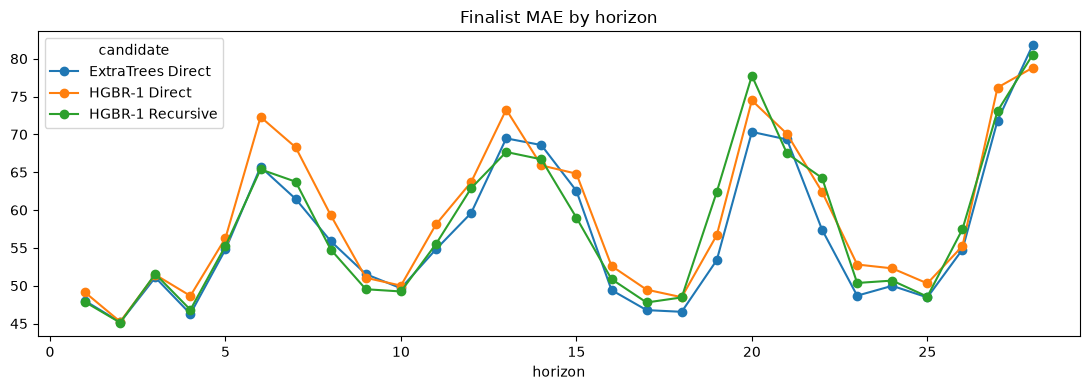

,training_rows,memory_mb,build_seconds,fit_seconds,forecast_seconds,model_mb,clipped
candidate,,,,,,,
HGBR-1 Recursive Weekly Sensitivity,15960.0,4.951910,0.215918,0.796940,0.203224,0.489338,0
HGBR-1 Recursive,113330.0,35.088051,1.431062,1.252267,0.211532,0.483078,0
HGBR-5 Recursive,113330.0,35.088051,1.431062,1.543306,0.244535,0.633727,0
HGBR-6 Recursive,113330.0,35.088051,1.431062,1.582368,0.243890,0.632506,0
HGBR-2 Recursive,113330.0,35.088051,1.431062,1.737771,0.250570,0.707089,0
HGBR-3 Recursive,113330.0,35.088051,1.431062,2.006908,0.279253,0.784627,0
HGBR-4 Recursive,113330.0,35.088051,1.431062,2.623515,0.258948,1.238293,0
HGBR-1 Direct,446880.0,138.786769,2.747401,2.723529,0.006670,0.498385,0
HGBR-6 Direct,446880.0,138.786769,2.747401,3.457347,0.009185,0.654649,0


In [8]:
leaders=list(dict.fromkeys(['HGBR-1 Direct','HGBR-1 Recursive',summary.sort_values('macro_rmsse').candidate.iloc[0]])); h=all_horizons[all_horizons.candidate.isin(leaders)].copy(); h['block']=pd.cut(h.horizon,[0,7,14,21,28],labels=['1-7','8-14','15-21','22-28'])
blocks=h.groupby(['candidate','block'],observed=True).agg(mae=('error',lambda x:x.abs().mean()),actual_total=('actual','sum'),signed_error=('error','sum')).reset_index(); blocks['bias']=blocks.signed_error/blocks.actual_total; display(blocks.drop(columns=['actual_total','signed_error']))
curve=h.groupby(['candidate','horizon']).error.apply(lambda x:x.abs().mean()).unstack('candidate'); curve.plot(marker='o',figsize=(11,4),title='Finalist MAE by horizon'); plt.tight_layout(); plt.show()
profile_summary=all_profiles.groupby('candidate').agg(training_rows=('training_rows','mean'),memory_mb=('memory_mb','mean'),build_seconds=('build_seconds','mean'),fit_seconds=('fit_seconds','mean'),forecast_seconds=('forecast_seconds','mean'),model_mb=('model_mb','mean'),clipped=('clipped','sum')); display(profile_summary.sort_values('fit_seconds'))

## Decision boundary
Apply the predeclared 1% rule to the eligible leader and runner-up, then review folds, series, WAPE, bias, model size, and inference. Freeze only if the combined evidence supports one operational candidate. The sensitivity result indicates whether daily-origin density plausibly explains the prior recursive advantage. No lockbox evaluation follows automatically.